# <center><font color='green'>Desafío 6 - Prediciendo las ventas de una tienda</font></center>

In [1]:
# Importamos las bibliotecas necesarías.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

In [2]:
# Creamos el dataframe usando 'pd.read_excel()'.
df= pd.read_excel('Sales_Data.xlsx')

# Mostramos el dataframe creado.
df

,Order Date,Sales
0,2015-01-01,14205.7070
1,2015-02-01,4519.8920
2,2015-03-01,55205.7970
3,2015-04-01,27906.8550
4,2015-05-01,23644.3030
5,2015-06-01,34322.9356
6,2015-07-01,33781.5430
7,2015-08-01,27117.5365
8,2015-09-01,81623.5268
9,2015-10-01,31453.3930


In [3]:
# Vista general del dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  48 non-null     datetime64[ns]
 1   Sales       48 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 900.0 bytes


1. Descomposición de la Serie de Tiempo: Comienza descomponiendo la serie de
tiempo en sus componentes principales: tendencia, estacionalidad y residuos. Utiliza
métodos como el suavizamiento exponencial o la descomposición estacional para
comprender la estructura subyacente de los datos.

In [4]:
# Seteamos el index.
df = df.set_index('Order Date')
result = seasonal_decompose(df['Sales'], model='additive', period=12)

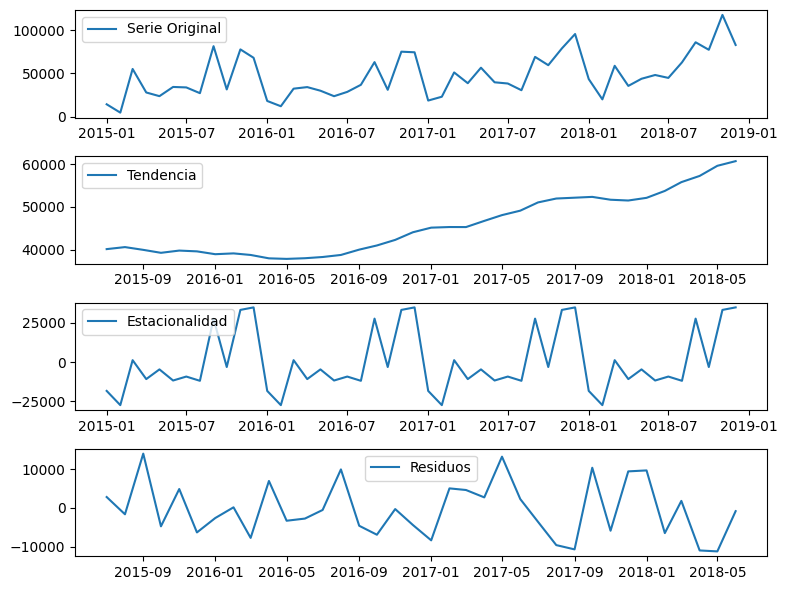

In [5]:
# Descomponemos la serie de tiempo en componentes.
result = seasonal_decompose(df, model='additive')

# Graficamos los componentes.
plt.figure(figsize=(8, 6))
plt.subplot(4, 1, 1)
plt.plot(df, label='Serie Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Estacionalidad')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residuos')
plt.legend()

plt.tight_layout()
plt.show()

#### Comentarios:
- La serie temporal de ventas presenta una tendencia creciente a partir de 2016, junto con una estacionalidad anual bien definida caracterizada por picos recurrentes hacia finales de cada año.
- Los residuos se comportan como ruido aleatorio sin patrones evidentes.

2. Identificación de Parámetros ARIMA: Utiliza las funciones de autocorrelación (ACF) y
autocorrelación parcial (PACF) para identificar los posibles valores de los parámetros
p (orden del término autorregresivo) y q (orden del término de media móvil) en el
modelo ARIMA. Además, realiza el test de Dickey-Fuller para determinar si es
necesario aplicar la diferenciación (valor d) para lograr la estacionaridad.

p-value: 0.00027791039276670623
d = 0


<Figure size 640x480 with 0 Axes>

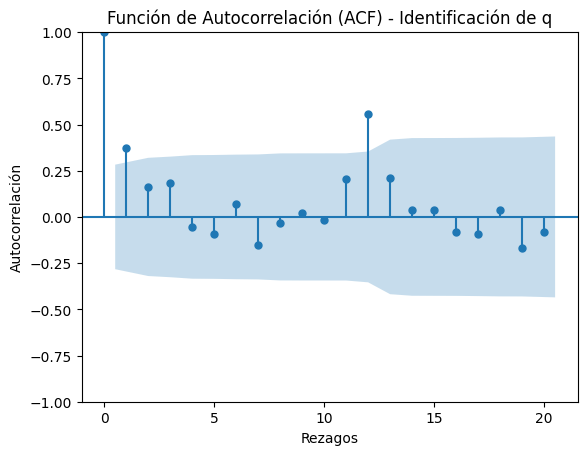

<Figure size 640x480 with 0 Axes>

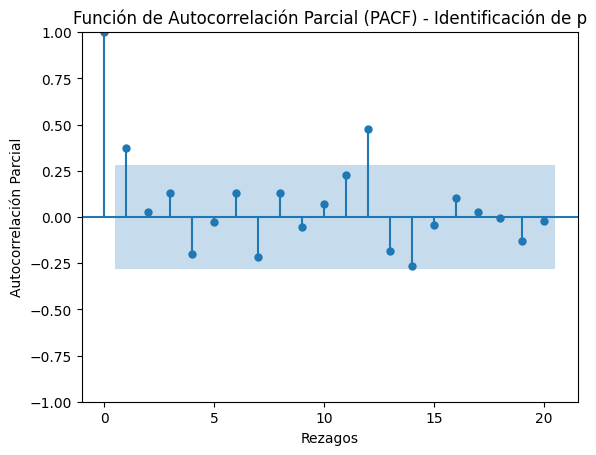

In [39]:
# Test ADF (para determinar d).
result = adfuller(df['Sales'])
print(f'p-value: {result[1]}')

if result[1] < 0.05:
    d = 0
    series = df['Sales']
else:
    d = 1
    series = df['Sales'].diff().dropna()

print(f'd = {d}')

# ACF (ayuda a elegir q).
plt.figure()
plot_acf(series, lags=20)
plt.title('Función de Autocorrelación (ACF) - Identificación de q')
plt.xlabel('Rezagos')
plt.ylabel('Autocorrelación')

# PACF (ayuda a elegir p).
plt.figure()
plot_pacf(series, lags=20)
plt.title('Función de Autocorrelación Parcial (PACF) - Identificación de p')
plt.xlabel('Rezagos')
plt.ylabel('Autocorrelación Parcial')

plt.show()

#### Comentarios:
El test de Dickey-Fuller indica que la serie es estacionaria (p-value < 0.05), por lo que no se requiere diferenciación (d = 0). A partir del análisis de los gráficos ACF y PACF, se observa un corte significativo en el rezago 1 en ambos casos, lo que sugiere valores p = 1 y q = 1. Asimismo, se identifica un pico en el rezago 12, indicando la presencia de estacionalidad anual.

3. Modelado con ARIMA: Aplica el modelo ARIMA utilizando los parámetros
identificados en el paso anterior. Ajusta el modelo a los datos históricos de ventas
mensuales y realiza predicciones para los próximos meses.

C:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


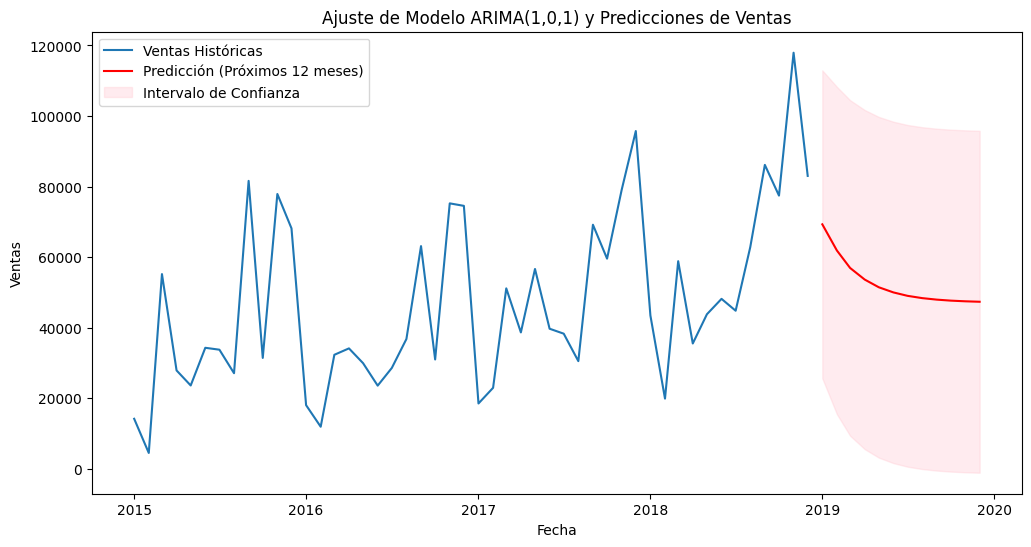

In [6]:
# Ajustamos el modelo ARIMA.
# Usamos los parámetros identificados: p=1, d=0, q=1.
model = ARIMA(df['Sales'], order=(1, 0, 1))
model_fit = model.fit()

# Realizamos las predicciones para los próximos 12 meses.
forecast_steps = 12
forecast_res = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

# Creamos un índice de fechas para las predicciones.
forecast_index = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), 
                               periods=forecast_steps, freq='MS')

# Visualizamos los resultados.
plt.figure(figsize=(12, 6))
plt.plot(df['Sales'], label='Ventas Históricas')
plt.plot(forecast_index, forecast_mean, color='red', label='Predicción (Próximos 12 meses)')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confianza')
plt.title('Ajuste de Modelo ARIMA(1,0,1) y Predicciones de Ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.show()

##### Comentarios:
El modelo ARIMA(1,0,1) de la serie de ventas mensuales, logra capturar la dependencia temporal de corto plazo mediante los componentes autorregresivo y de media móvil. El modelo presenta un ajuste razonable sobre los datos históricos, sin embargo, las predicciones tienden a estabilizarse hacia la media y no logran reproducir los picos observados en la serie. Esto sugiere que, si bien el modelo es adecuado como aproximación inicial, no captura completamente la estacionalidad presente en los datos.

4. Evaluación de Predicciones: Divide los datos históricos en un conjunto de
entrenamiento y uno de prueba. Utiliza el conjunto de entrenamiento para ajustar el
modelo ARIMA y luego evalúa las predicciones en el conjunto de prueba. Calcula
métricas de evaluación como el error cuadrático medio (MSE) o el error absoluto
medio (MAE) para medir el rendimiento del modelo.

In [41]:
# División en entrenamiento y prueba (80% entrenamiento, 20% prueba).
train_size = int(len(df) * 0.8)
train, test = df['Sales'][0:train_size], df['Sales'][train_size:len(df)]

print(f"Observaciones de entrenamiento: {len(train)}")
print(f"Observaciones de prueba: {len(test)}")

Observaciones de entrenamiento: 38
Observaciones de prueba: 10


In [42]:
# Ajustamos el modelo ARIMA(1,0,1) solo con los datos de entrenamiento.
model_train = ARIMA(train, order=(1, 0, 1))
model_train_fit = model_train.fit()

# Realizamos la predicción sobre el tamaño del conjunto de prueba.
pred_manual = model_train_fit.forecast(steps=len(test))

C:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [43]:
# Vamos a usar auto ARIMA.
auto_model = auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=866.928, Time=0.35 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=873.210, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=867.255, Time=0.05 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=865.014, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=928.679, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=872.991, Time=0.02 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=866.356, Time=0.07 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=863.723, Time=0.18 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=865.594, Time=0.10 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=864.184, Time=0.07 sec
 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=865.520, Time=0.13 sec
 ARIMA(0,0,2)(0,0,2)[12] intercept   : AIC=866.139, Time=0.10 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=863.949, Time=0.09 sec
 ARIMA(1,0,2)(0,0,2)[12] intercept   : AIC=867.851, Time=0.14 sec
 ARIMA(0,0,1)(0,0,2)[12]         

In [44]:
# Predicción sobre el test.
pred_auto = auto_model.predict(n_periods=len(test))

In [45]:
# Métricas.
mae = mean_absolute_error(test, pred_auto)
rmse = np.sqrt(mean_squared_error(test, pred_auto))
mape = np.mean(np.abs((test - pred_auto) / test)) * 100

print("--- AUTO ARIMA ---")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

mae_m = mean_absolute_error(test, pred_manual)
rmse_m = np.sqrt(mean_squared_error(test, pred_manual))
mape_m = np.mean(np.abs((test - pred_manual) / test)) * 100

print("--- ARIMA MANUAL ---")
print(f"MAE: {mae_m}")
print(f"RMSE: {rmse_m}")
print(f"MAPE: {mape_m}")

--- AUTO ARIMA ---
MAE: 20136.829402047217
RMSE: 25803.372795381503
MAPE: 27.01119330691394
--- ARIMA MANUAL ---
MAE: 25478.756171058893
RMSE: 33956.322834541534
MAPE: 32.090557452493876


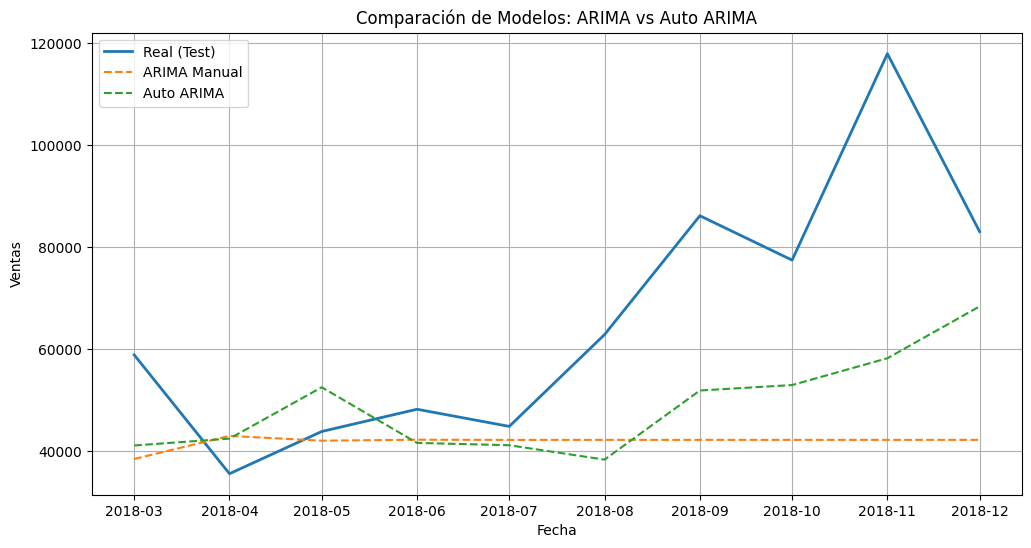

In [46]:
# Visualizacion de la comparación.
plt.figure(figsize=(12,6))

# Serie real (test).
plt.plot(test.index, test, label='Real (Test)', linewidth=2)

# Predicción ARIMA manual.
plt.plot(test.index, pred_manual, label='ARIMA Manual', linestyle='--')

# Predicción Auto ARIMA.
plt.plot(test.index, pred_auto, label='Auto ARIMA', linestyle='--')

plt.title('Comparación de Modelos: ARIMA vs Auto ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid()

plt.show()

#### Conclusiones:
Se comparó el desempeño del modelo ARIMA manual con un modelo Auto ARIMA utilizando métricas de error sobre el conjunto de prueba. Los resultados muestran que el modelo Auto ARIMA presenta menores valores de MAE, RMSE y MAPE, lo que indica una mejor capacidad predictiva. A nivel visual, el modelo automático se ajusta mejor a la dinámica de la serie, mientras que el modelo manual presenta predicciones más planas y alejadas de los valores reales. Esto se debe a que Auto ARIMA incorpora componentes estacionales, capturando de manera más efectiva los patrones presentes en los datos. En consecuencia, el modelo Auto ARIMA resulta más adecuado para la predicción de esta serie temporal.